In [2]:
#Questão 1

"""
a regressão linear simples tem como objetivo estabelecer uma relação entre um valor variavel x e seu valor correspondente 
esperado y, na forma ax+b=y. Na equação, que tem o formato y = α + βx + ε, α é o ponto de interseção com o eixo y, sendo o valor de f(0).
β é o declive, se o x aumenta em 1, o y aumenta β
"""

'\na regressão linear simples tem como objetivo estabelecer uma relação entre um valor variavel x e seu valor correspondente \nesperado y, na forma ax+b=y. Na equação, que tem o formato y = α + βx + ε, α é o ponto de interseção com o eixo y, sendo o valor de f(0).\nβ é o declive, se o x aumenta em 1, o y aumenta β\n'

In [3]:
#Questão 2

"""
O coeficiente de pearson mede o grau de correlação linear entre duas variaveis x e y, além de indicar se a relação é positiva ou negativa.
ρ = 0.85 indica uma relação positiva e forte
ρ = −0.65 indica uma relação negativa moderada
ρ = 0.10 indica relação positiva desprezível
"""

'\nO coeficiente de pearson mede o grau de correlação linear entre duas variaveis x e y, além de indicar se a relação é positiva ou negativa.\nρ = 0.85 indica uma relação positiva e forte\nρ = −0.65 indica uma relação negativa moderada\nρ = 0.10 indica relação positiva desprezível\n'

In [20]:
#Questão 3 e 4

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import linregress

data = fetch_california_housing(as_frame=True)
print(data.data.columns) #colunas do dataset
print(data.target.name) #nome do target
print('\n')

X = data.data
Y = data.target

train_x, test_x, train_y, test_y = train_test_split(X, Y, random_state=12)

modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

modelo.fit(train_x, train_y)
r2 = modelo.score(test_x, test_y) # faz o predict e já calcula o r2

print(f'R2 : {r2:.4%}')
print(f'R2 (outro jeito de calcular): {r2_score(test_y, modelo.predict(test_x)):.4%}') # funçao r2score + predict
print('\n')

#por cross validation
scores_r2 = cross_val_score(modelo, X, Y, cv=10)
print(f'R2 médio: {np.mean(scores_r2):.4%}')
print('\n')

print('Um r2 médio em volta de 50% significa que o modelo tem domínio sobre metade da previsão dos dados, como se ele entendesse metade do que esta acontecendo')

#coeficientes
print(f'Alpha: {modelo["linear"].intercept_:.4f}')

tabela_betas = pd.DataFrame({
    'Coluna (Feature)': X.columns,
    'Beta': modelo["linear"].coef_
})
tabela_betas['Beta Absoluto'] = tabela_betas['Beta'].apply( lambda x : -x if x<0 else x)

print('Betas (Um para cada coluna / variável): ')
display(tabela_betas.sort_values(by=['Beta Absoluto'], ascending=[False]))

pearsons = []

for coluna in X.columns: pearsons.append(linregress(X[coluna], Y).rvalue)

tabela_pearsons = pd.DataFrame({
    "Coluna / Feature" : X.columns,
    "Pearson" : pearsons
})
print('Pearsons por Feature: ')
display(tabela_pearsons.sort_values(by=['Pearson'], ascending=[False]))




Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')
MedHouseVal


R2 : 60.6009%
R2 (outro jeito de calcular): 60.6009%


R2 médio: 51.1007%


Um r2 médio em volta de 50% significa que o modelo tem domínio sobre metade da previsão dos dados, como se ele entendesse metade do que esta acontecendo
Alpha: 2.0631
Betas (Um para cada coluna / variável): 


,Coluna (Feature),Beta,Beta Absoluto
6,Latitude,-0.909055,0.909055
7,Longitude,-0.879774,0.879774
0,MedInc,0.817610,0.817610
3,AveBedrms,0.305232,0.305232
2,AveRooms,-0.261019,0.261019
1,HouseAge,0.119417,0.119417
5,AveOccup,-0.039710,0.039710
4,Population,-0.001223,0.001223


Pearsons por Feature: 


,Coluna / Feature,Pearson
0,MedInc,0.688075
2,AveRooms,0.151948
1,HouseAge,0.105623
5,AveOccup,-0.023737
4,Population,-0.024650
7,Longitude,-0.045967
3,AveBedrms,-0.046701
6,Latitude,-0.144160


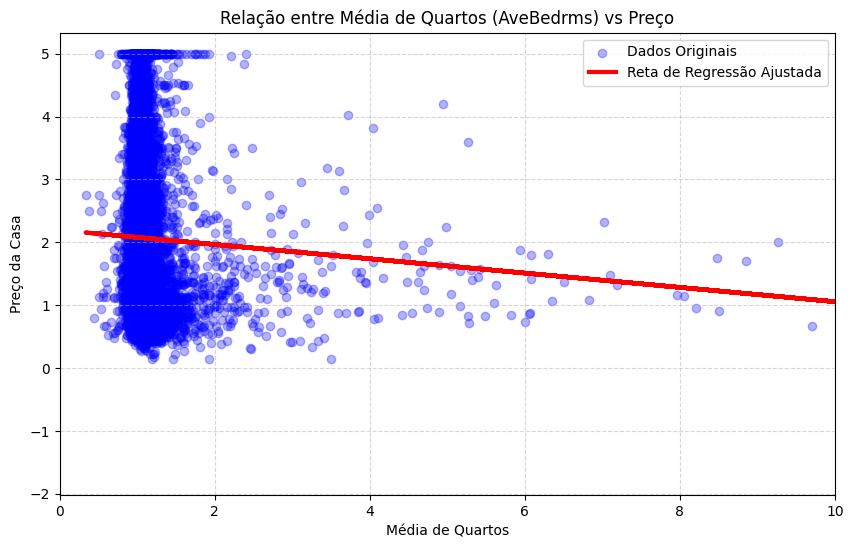

In [ ]:
# Questão 5

X_simples = data.frame[['AveBedrms']]

modelo_simples = LinearRegression() #novo modelo 2d
modelo_simples.fit(X_simples, Y)
Y_pred_simples = modelo_simples.predict(X_simples)

plt.figure(figsize=(10, 6))
plt.scatter(X_simples, Y, color='blue', alpha=0.3, label='Dados Originais')
plt.plot(X_simples, Y_pred_simples, color='red', linewidth=3, label='Reta de Regressão Ajustada')

plt.title('Relação entre Média de Quartos (AveBedrms) vs Preço')
plt.xlabel('Média de Quartos')
plt.ylabel('Preço da Casa')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlim(0, 10) # limita o gráfico até 10 para nao pegar outliers
plt.show()



In [ ]:
# Questão 6 e 7

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

data = fetch_california_housing(as_frame=True)

X = data.data
Y = data.target

x_train, x_test, y_train, y_test = train_test_split(X,Y, random_state=123)

modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
]) #Normalizar,Transformar e usar os dados na regressão linear direto

modelo.fit(x_train, y_train)

r2 = cross_val_score(modelo, X, Y, cv=10)
print(f'R2 médio: {np.mean(r2):.4%}')
print(r2)

r2_treino = modelo.score(x_train, y_train)
r2_teste = modelo.score(x_test, y_test)

print(f'R2 de treino: {r2_treino:.4%}, R2 de teste: {r2_teste:.4%}')
print('Como eles têm valores parecidos, não há evidencia de overfiting (:')
print('\n')
print('Porém, um dos r2 da cross_validation tem um r2 totalmente fora de padrão, o que bagunçou completamente a média ):')
print("""Como visto na outra célula, o modelo linear tinha um r2 em torno de 50%, enquanto o polinomial
com grau 2 tem em torno de 65%""")

R2 médio: -43.5800%
[ 0.5068899  -0.4053886   0.56077475  0.51974672  0.50645854  0.59570878
  0.38279436  0.53050525  0.51002428 -8.06551241]
R2 de treino: 68.0525%, R2 de teste: 63.1378%
Como eles têm valores parecidos, não há evidencia de overfiting


Porém, um dos r2 da cross_validation tem um r2 totalmente fora de padrão, o que bagunçou completamente a média ):
Como visto na outra célula, o modelo linear tinha um r2 em torno de 50%, enquanto o polinomial
com grau 2 tem em torno de 65%


In [ ]:
# Questão 8

"""
A regressão multivariada também é linear, porém usa várias variáveis, cada um tendo seu Beta
e cada variável tendo um impacto diferente. Nas questões anteriores foram mostrados os Betas e seus valores,
como o MedInc, Latitude e Longitude (devemos analisar o impacto pelo módulo!)
"""

''

In [ ]:
#Questão 9

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor

data = fetch_california_housing(as_frame=True)

X = data.data
Y = data.target

medias_r2 = []
ks = [3,5,7,9,11,13]

for k in ks:

    modelo = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k))
    ])

    medias_r2.append(np.mean(cross_val_score(modelo, X, Y, cv=5)))

tabela_k_r2 = pd.DataFrame({
    'K': ks,
    'R2 Médio': medias_r2
})

print('R2 médio para cada K:')
display(tabela_k_r2.sort_values(by=['R2 Médio'], ascending=[False]))

'''O k ideal ficou entre 5 e 7, k maiores tem custo computacional muito alto e nao aumentam significativamente o r2 médio
e k menores tem um r2 medio levemente inferior'''
    

R2 médio para cada K:


,K,R2 Médio
5,13,0.551434
4,11,0.549485
3,9,0.544909
2,7,0.536377
1,5,0.521186
0,3,0.479558


In [ ]:
#Questão 10

'''Modelos paramétricos são o "f(X)", se baseiam em variaveis e somente nelas, como a regressão linear e a polinomial,
já o knn é não paramétrico, se basenado em distãncia. Os modelos paramétricos são mais diretos, mais rápidos e leves, porém são mais limitados, pois tentam formar uma equação y = a + bx. A regressão polinomial 
é paramétrico, porém é mais flexível a curvas, porém, quanto mais aumenta o grau, mais aumenta o custo computacional e o risco de overfiting.
As regressões sofrem com com dados que formam curvas / padrões complexos e não seguem relações lineares, mas podem comseguir anular
variáveis que não influenciam no resultado final.
Já os não paramétricos são mais lentos e exigem mais computacionalemente, porém lidam muito bem com os padrões mais complexos,
entretanto, a quantidade de dimensões/variáveis pode inflar os conceitos de distãncia'''

'''A regressão linear é mais rápida, leve e trabalha melhor com mais variáveis, porém não é flexivel para a complexidade dos padrões'''

'''A regressão polinomial é equilibrada entre custo computacional e flexibilidade, sendo mais flexivel que a linear e mais leve que o knn,
sendo ótimo para lidar com padrões levemente mais complexos, mas não o suficiente para um knn'''